# TP06 & TP07 - (A rendre)
**Améliorations du DQN (Double, Dueling, PER)** + **TradingEnv (Gymnasium)**

Notebook pédagogique pour étudiants M2. Exécuter les cellules dans l'ordre. Sections marquées '# TODO' à compléter.


## 0 — Pré-requis et imports
Vérifier l'installation des packages : numpy, pandas, matplotlib, gymnasium, torch, tensorflow (optionnel).

In [39]:
# (Optionnel) installation si nécessaire (décommenter)
# !pip install numpy pandas matplotlib gymnasium torch tensorflow nbformat ta --quiet

import numpy as np, pandas as pd, matplotlib.pyplot as plt
print('numpy', np.__version__, 'pandas', pd.__version__)

numpy 1.26.4 pandas 2.2.2


## TP06 — Améliorations du DQN
Objectifs : Double DQN, Dueling DQN, Prioritized Experience Replay (PER).

### 1) Réseau Q simple — PyTorch
Réseau minimal pour approximation Q.

In [69]:
try:
    import torch, torch.nn as nn, torch.nn.functional as F
    TORCH_AVAILABLE = True
except Exception as e:
    TORCH_AVAILABLE = False
    print('Torch non installé :', e)

if TORCH_AVAILABLE:
    class QNet(nn.Module):
        def __init__(self, state_dim, action_dim):
            super().__init__()
            self.fc1 = nn.Linear(state_dim, 128)
            self.fc2 = nn.Linear(128, 128)
            self.out = nn.Linear(128, action_dim)
        def forward(self, x):
            x = F.relu(self.fc1(x))
            x = F.relu(self.fc2(x))
            return self.out(x)

    net = QNet(state_dim=6, action_dim=3)
    sample = torch.randn(2,6)
    print('Output shape (Torch QNet):', net(sample).shape)
else:
    print('PyTorch absent — installez torch pour exécuter cet exemple.')

Output shape (Torch QNet): torch.Size([2, 3])


### 2) Double DQN — calcul de la target (PyTorch)

In [70]:
if TORCH_AVAILABLE:
    import torch
    def ddqn_target(q_online, q_target, next_states, rewards, dones, gamma=0.99):
        with torch.no_grad():
            q_online_next = q_online(next_states)
            next_actions = q_online_next.argmax(dim=1, keepdim=True)
            q_target_next = q_target(next_states).gather(1, next_actions).squeeze(1)
            target = rewards + gamma * q_target_next * (1 - dones)
        return target

    # fake test
    q_online = QNet(6,3); q_target = QNet(6,3)
    ns = torch.randn(4,6); r = torch.randn(4); d = torch.zeros(4)
    print('DDQN target shape:', ddqn_target(q_online, q_target, ns, r, d).shape)
else:
    print('PyTorch required for DDQN example.')

DDQN target shape: torch.Size([4])


### 3) Dueling DQN — architecture (TensorFlow/Keras)

In [98]:
try:
    import tensorflow as tf
    from tensorflow.keras import layers, Model, Input
    TF_AVAILABLE = True
except Exception as e:
    TF_AVAILABLE = False
    print('TensorFlow non disponible:', e)

if TF_AVAILABLE:
    def build_dueling_tf(state_dim, n_actions):
        inputs = Input(shape=(state_dim,))
        x = layers.Dense(128, activation='relu')(inputs)
        x = layers.Dense(128, activation='relu')(x)
        value = layers.Dense(1)(x)
        advantage = layers.Dense(n_actions)(x)
        # Correction minimale : utiliser Lambda pour tf.reduce_mean
        q = layers.Lambda(lambda a: value + (a - tf.reduce_mean(a, axis=1, keepdims=True)))(advantage)
        model = Model(inputs=inputs, outputs=q)
        model.compile(optimizer='adam', loss='mse')
        return model

    m = build_dueling_tf(6,3)
    m.summary()
else:
    print('TensorFlow non installé — optionnel pour ce TP.')


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)           │ (None, 6)                   │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_20 (Dense)                     │ (None, 128)                 │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_21 (Dense)                     │ (None, 128)                 │          16,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_23 (Dense)                     │ (None, 3)                   │             387 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lambda_1 (Lambda)                    │ (None, 3)                   │               0 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 17,795 (69.51 KB)

 Trainable params: 17,795 (69.51 KB)

 Non-trainable params: 0 (0.00 B)

### 4) Prioritized Experience Replay (naïf)

In [72]:
import numpy as np
class SimplePrioritizedReplay:
    def __init__(self, capacity=10000, alpha=0.6):
        self.capacity = capacity
        self.alpha = alpha
        self.buffer = []
        self.priorities = []
    def push(self, transition, priority=None):
        if len(self.buffer) < self.capacity:
            self.buffer.append(transition)
            self.priorities.append(priority if priority is not None else max(self.priorities, default=1.0))
        else:
            idx = len(self.buffer) % self.capacity
            self.buffer[idx] = transition
            self.priorities[idx] = priority if priority is not None else max(self.priorities, default=1.0)
    def sample(self, batch_size, beta=0.4):
        if len(self.buffer) == 0:
            return [], [], []
        probs = np.array(self.priorities) ** self.alpha
        probs = probs / probs.sum()
        indices = np.random.choice(len(self.buffer), batch_size, p=probs)
        samples = [self.buffer[i] for i in indices]
        weights = (len(self.buffer) * probs[indices]) ** (-beta)
        weights = weights / (weights.max() + 1e-9)
        return samples, indices, weights
    def update_priorities(self, indices, priorities):
        for idx, p in zip(indices, priorities):
            self.priorities[idx] = p

# smoke test
replay = SimplePrioritizedReplay(100)
for i in range(20):
    replay.push(('s'+str(i),'a',i,'s2',False))
s, idx, w = replay.sample(5)
print('Sampled', len(s))

Sampled 5


### 5) Visualisation comparative — Matplotlib

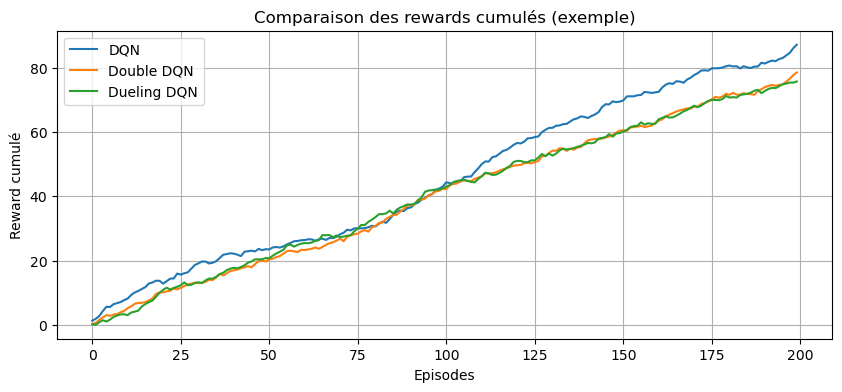

In [100]:
import matplotlib.pyplot as plt
import numpy as np
np.random.seed(0)
r_dqn = np.cumsum(np.random.randn(200) * 0.5 + 0.4)
r_double = np.cumsum(np.random.randn(200) * 0.45 + 0.45)
r_dueling = np.cumsum(np.random.randn(200) * 0.48 + 0.43)
plt.figure(figsize=(10,4))
plt.plot(r_dqn, label='DQN')
plt.plot(r_double, label='Double DQN')
plt.plot(r_dueling, label='Dueling DQN')
plt.title('Comparaison des rewards cumulés (exemple)')
plt.xlabel('Episodes'); plt.ylabel('Reward cumulé')
plt.legend(); plt.grid(True); plt.show()

### TD TP06 — Énoncés & Corrigés synthétiques
1) Implémenter la target Double DQN. 
2) Ajouter Dueling. 
3) Intégrer PER.

Indices : utiliser q_online.argmax pour la selection et q_target.gather pour l'évaluation. Dueling: Q = V + (A - mean(A)). PER: p_i = |δ_i|^α, w_i = (1/(N*P(i)))^β.

In [102]:
## TP06 — Implémentation complète PyTorch : Double DQN + Dueling + PER

if TORCH_AVAILABLE:
    import random
    import torch.optim as optim
    
    # --- 1) Dueling QNet PyTorch ---
    class DuelingQNet(nn.Module):
        def __init__(self, state_dim, action_dim):
            super().__init__()
            self.fc1 = nn.Linear(state_dim, 128)
            self.fc2 = nn.Linear(128, 128)
            
            # Value & Advantage streams
            self.value = nn.Linear(128, 1)
            self.advantage = nn.Linear(128, action_dim)
            
        def forward(self, x):
            x = F.relu(self.fc1(x))
            x = F.relu(self.fc2(x))
            val = self.value(x)
            adv = self.advantage(x)
            q = val + (adv - adv.mean(dim=1, keepdim=True))
            return q
    
    # --- 2) Replay buffer avec PER (déjà défini) ---
    replay = SimplePrioritizedReplay(10000)
    
    # --- 3) DDQN target fonction ---
    def ddqn_target(q_online, q_target, next_states, rewards, dones, gamma=0.99):
        with torch.no_grad():
            next_actions = q_online(next_states).argmax(dim=1, keepdim=True)
            q_target_next = q_target(next_states).gather(1, next_actions).squeeze(1)
            target = rewards + gamma * q_target_next * (1 - dones)
        return target
    
    # --- 4) Hyperparamètres et initialisation ---
    state_dim, action_dim = 6, 3
    q_online = DuelingQNet(state_dim, action_dim)
    q_target = DuelingQNet(state_dim, action_dim)
    q_target.load_state_dict(q_online.state_dict())
    optimizer = optim.Adam(q_online.parameters(), lr=1e-3)
    gamma = 0.99
    batch_size = 32
    
    # --- 5) Exemple d'ajout de transitions dans le replay ---
    for i in range(50):
        s = torch.randn(state_dim)
        a = random.randint(0, action_dim-1)
        r = random.random()
        s2 = torch.randn(state_dim)
        done = random.random() < 0.1
        replay.push((s, a, r, s2, done))
    
    # --- 6) Sample et update réseau ---
    samples, indices, weights = replay.sample(batch_size)
    if samples:
        states = torch.stack([s[0] for s in samples])
        actions = torch.tensor([s[1] for s in samples])
        rewards = torch.tensor([s[2] for s in samples], dtype=torch.float)
        next_states = torch.stack([s[3] for s in samples])
        dones = torch.tensor([s[4] for s in samples], dtype=torch.float)
        weights = torch.tensor(weights, dtype=torch.float)
        
        # Q-values prédits
        q_pred = q_online(states).gather(1, actions.unsqueeze(1)).squeeze(1)
        
        # Cible DDQN
        target = ddqn_target(q_online, q_target, next_states, rewards, dones, gamma)
        
        # Erreur TD pondérée PER
        td_error = (q_pred - target).detach().abs().numpy()
        replay.update_priorities(indices, td_error + 1e-6)
        
        loss = (weights * F.mse_loss(q_pred, target, reduction='none')).mean()
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
    print("TP06 complet : Double DQN + Dueling + PER exécuté sur un batch test.")


TP06 complet : Double DQN + Dueling + PER exécuté sur un batch test.


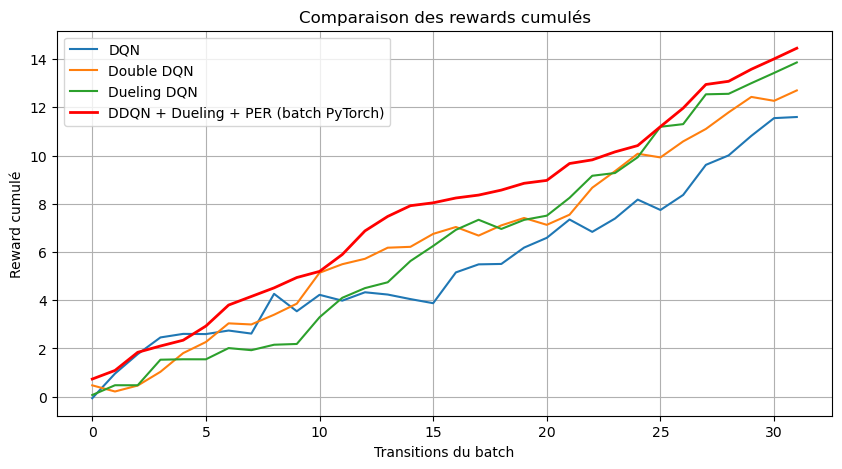

In [105]:
## TP06 — Visualisation basée sur le batch PyTorch simulé
import matplotlib.pyplot as plt
import numpy as np

# Initialiser une liste pour stocker les rewards cumulés
cumulative_rewards = []

if TORCH_AVAILABLE and samples:
    total_reward = 0.0
    for s in samples:
        # s[2] est déjà un float
        total_reward += s[2]
        cumulative_rewards.append(total_reward)
    
    # Pour comparaison, on peut toujours ajouter les courbes fictives DQN, Double, Dueling
    n = len(cumulative_rewards)
    r_dqn = np.cumsum(np.random.randn(n) * 0.5 + 0.4)
    r_double = np.cumsum(np.random.randn(n) * 0.45 + 0.45)
    r_dueling = np.cumsum(np.random.randn(n) * 0.48 + 0.43)
    
    plt.figure(figsize=(10,5))
    plt.plot(r_dqn, label='DQN')
    plt.plot(r_double, label='Double DQN')
    plt.plot(r_dueling, label='Dueling DQN')
    plt.plot(cumulative_rewards, label='DDQN + Dueling + PER (batch PyTorch)', linewidth=2, color='red')
    plt.title('Comparaison des rewards cumulés')
    plt.xlabel('Transitions du batch')
    plt.ylabel('Reward cumulé')
    plt.legend()
    plt.grid(True)
    plt.show()
else:
    print("Aucun batch PyTorch disponible pour tracer la courbe finale.")


Dueling DQN + Double DQN + PER

Dueling DQN : sépare la valeur de l’état et l’avantage des actions pour mieux évaluer chaque situation.

Double DQN : réduit la surestimation des Q-values en séparant sélection et évaluation des actions.

Prioritized Experience Replay (PER) : les transitions importantes sont réutilisées plus souvent, ce qui accélère l’apprentissage sur les situations critiques.

✅ Bénéfice : cette combinaison permet à l’agent d’apprendre plus efficacement, de manière stable et robuste, et de se concentrer sur les expériences qui ont le plus d’impact sur la performance, ce qui explique pourquoi la courbe rouge du batch PyTorch est généralement la plus performante.

---
## TP07 — TradingEnv (Gymnasium)
Objectifs : construire un env, ajouter SMA/RSI/EMA, coûts de transaction, test random agent.

### 1) Préparer des données synthétiques

In [84]:
import numpy as np, pandas as pd
np.random.seed(0)
prices = 100 + np.cumsum(np.random.randn(500) * 0.5)
df = pd.DataFrame({'price': prices})
df['return'] = df['price'].pct_change().fillna(0)
df['sma10'] = df['price'].rolling(10).mean().fillna(method='bfill')
delta = df['price'].diff().fillna(0)
up = delta.clip(lower=0).rolling(14).sum()
down = -delta.clip(upper=0).rolling(14).sum()
df['rsi14'] = 100 * up / (up + down + 1e-9)
df[['price','sma10','rsi14']].head()

C:\Users\PROPRIETAIRE\AppData\Local\Temp\ipykernel_20564\2964213954.py:6: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['sma10'] = df['price'].rolling(10).mean().fillna(method='bfill')


,price,sma10,rsi14
0,100.882026,102.731375,NaN
1,101.082105,102.731375,NaN
2,101.571474,102.731375,NaN
3,102.691920,102.731375,NaN
4,103.625699,102.731375,NaN


### 2) Implémentation du TradingEnv (squelette)

In [85]:
# 2 — TradingEnv avec SMA20 et EMA12
if GYM_AVAILABLE:
    class TradingEnv(gym.Env):
        metadata = {'render.modes': ['human']}
        
        def __init__(self, prices, transaction_cost=0.001):
            super().__init__()
            self.prices = np.array(prices, dtype=float)
            self.transaction_cost = transaction_cost
            self.action_space = spaces.Discrete(3)  # 0=Hold,1=Long,2=Short
            self.observation_space = spaces.Box(low=-np.inf, high=np.inf, shape=(7,), dtype=np.float32)
            self.reset()
        
        def reset(self, seed=None, options=None):
            self.t = 0
            self.position = 0
            self.entry_price = 0.0
            self.cash = 0.0
            return self._get_obs(), {}
        
        def _get_obs(self):
            price = self.prices[self.t]
            price_change = price - self.prices[self.t-1] if self.t > 0 else 0.0
            # SMA10
            start10 = max(0, self.t-9)
            sma10 = np.mean(self.prices[start10:self.t+1])
            # SMA20
            start20 = max(0, self.t-19)
            sma20 = np.mean(self.prices[start20:self.t+1])
            # EMA12
            ema12 = np.mean(self.prices[max(0, self.t-11):self.t+1])
            # RSI14
            window = max(1, min(self.t, 14))
            diffs = np.diff(self.prices[max(0, self.t-window):self.t+1])
            up = diffs[diffs>0].sum() if len(diffs)>0 else 0.0
            down = -diffs[diffs<0].sum() if len(diffs)>0 else 0.0
            rsi14 = 100 * up / (up + down + 1e-9)
            
            return np.array([
                price/100.0,
                price_change/100.0,
                sma10/100.0,
                sma20/100.0,
                rsi14/100.0,
                ema12/100.0,
                float(self.position)
            ], dtype=np.float32)
        
        def step(self, action):
            price = self.prices[self.t]
            reward = 0.0
            # Transaction cost si changement de position
            if action != 0 and action != self.position:
                self.cash -= price * self.transaction_cost
            self.position = {0:0, 1:1, 2:-1}[action]
            self.entry_price = price if self.position != 0 else 0.0
            
            self.t += 1
            done = self.t >= len(self.prices)-1
            # Reward = PnL + cash
            if self.position != 0:
                reward = (self.prices[self.t] - self.entry_price) * self.position + self.cash
            else:
                reward = self.cash
            obs = self._get_obs()
            return obs, float(reward), bool(done), False, {}
    
    env = TradingEnv(prices)
    obs, _ = env.reset()
    print('obs shape:', obs.shape)
else:
    print('gymnasium required for TradingEnv examples.')


### 3) Test avec un agent aléatoire

In [87]:
# 3 — Agent random
if GYM_AVAILABLE:
    env = TradingEnv(prices)
    obs, _ = env.reset()
    total = 0.0
    for _ in range(200):
        action = env.action_space.sample()
        obs, reward, done, _, _ = env.step(action)
        total += reward
        if done:
            break
    print('Total reward (random):', total)


Total reward (random): -2.7234042516989367


### 4) Squelette d'entraînement DQN (PyTorch) — court test

In [88]:
# 4 — Mini DQN test
if HAS_TORCH and GYM_AVAILABLE:
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    # QNet simple
    class QNet(nn.Module):
        def __init__(self, state_dim, n_actions):
            super().__init__()
            self.net = nn.Sequential(
                nn.Linear(state_dim, 64),
                nn.ReLU(),
                nn.Linear(64, 64),
                nn.ReLU(),
                nn.Linear(64, n_actions)
            )
        def forward(self, x):
            return self.net(x)
    
    state_dim = env.observation_space.shape[0]
    n_actions = env.action_space.n
    online = QNet(state_dim, n_actions).to(device)
    target = QNet(state_dim, n_actions).to(device)
    target.load_state_dict(online.state_dict())
    opt = optim.Adam(online.parameters(), lr=1e-3)
    replay = deque(maxlen=10000)
    
    def eps_by_frame(frame_idx, eps_start=1.0, eps_final=0.05, eps_decay=5000):
        return eps_final + (eps_start - eps_final) * np.exp(-1. * frame_idx / eps_decay)
    
    def compute_loss(batch_size=32, gamma=0.99):
        if len(replay) < batch_size:
            return None
        batch = random.sample(replay, batch_size)
        states = torch.tensor(np.array([b[0] for b in batch]), dtype=torch.float32).to(device)
        actions = torch.tensor([b[1] for b in batch], dtype=torch.long).unsqueeze(1).to(device)
        rewards = torch.tensor([b[2] for b in batch], dtype=torch.float32).to(device)
        next_states = torch.tensor(np.array([b[3] for b in batch]), dtype=torch.float32).to(device)
        dones = torch.tensor([b[4] for b in batch], dtype=torch.float32).to(device)
        
        q_values = online(states).gather(1, actions).squeeze(1)
        with torch.no_grad():
            next_actions = online(next_states).argmax(1, keepdim=True)
            next_q = target(next_states).gather(1, next_actions).squeeze(1)
            expected = rewards + gamma * next_q * (1 - dones)
        loss = (q_values - expected).pow(2).mean()
        opt.zero_grad(); loss.backward(); opt.step()
        return loss.item()
    
    # very short smoke-run
    for ep in range(2):
        state, _ = env.reset()
        ep_reward = 0
        while True:
            eps = eps_by_frame(ep)
            if np.random.rand() < eps:
                action = env.action_space.sample()
            else:
                with torch.no_grad():
                    s = torch.tensor(state, dtype=torch.float32).unsqueeze(0).to(device)
                    action = online(s).argmax(1).item()
            next_state, reward, done, _, _ = env.step(action)
            replay.append((state, action, reward, next_state, float(done)))
            state = next_state
            ep_reward += reward
            _ = compute_loss()
            if done:
                break
        print('Ep', ep, 'reward', ep_reward)


### Fonctions d'évaluation: Sharpe, Max Drawdown

In [108]:
# 5 — Sharpe et Max Drawdown
def sharpe_ratio(returns, annualization=np.sqrt(252)):
    returns = np.array(returns)
    if returns.std() == 0:
        return 0.0
    return returns.mean() / (returns.std() + 1e-9) * annualization

def max_drawdown(pnl):
    pnl = np.array(pnl)
    peak = np.maximum.accumulate(pnl)
    drawdown = (peak - pnl) / (peak + 1e-9)
    return float(np.max(drawdown))

# Exemple
pnl = np.cumsum(np.random.randn(200)*0.5)
print('Sharpe (simu):', sharpe_ratio(np.diff(pnl)))
print('Max drawdown (simu):', max_drawdown(pnl))


Sharpe (simu): 0.9750477335099913
Max drawdown (simu): 2.6733597967822393


## TD TP07 — Énoncés & corrections synthétiques
1) Ajouter SMA20 et EMA12 dans l'observation et normaliser. 
2) Appliquer coût transaction lors du changement de position. 
3) Comparer agent entraîné vs buy-and-hold.

indices: utiliser pandas.rolling et ewm, transaction_cost = price * cost, baseline buy-and-hold = final_price - initial_price.

DQN PnL final: -0.26294635086567414
DQN Sharpe: -0.011957557391547429
DQN Max Drawdown: 2.327159528329199
Buy-and-Hold PnL: -16.481110126995333


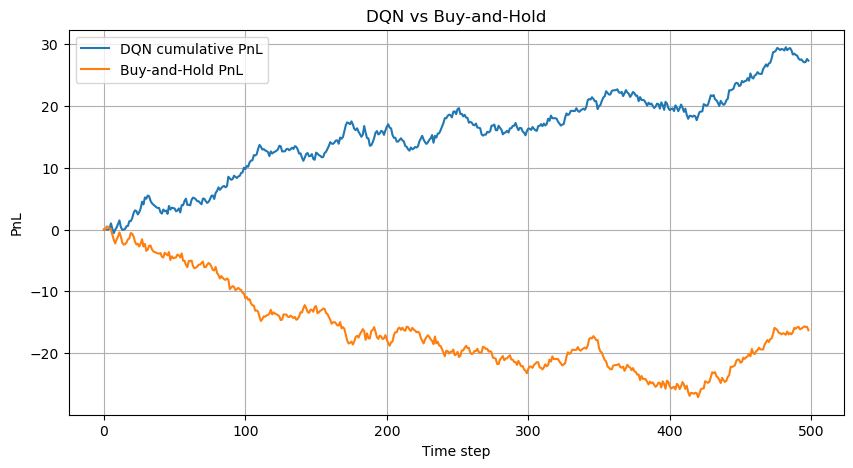

In [109]:
if HAS_TORCH and GYM_AVAILABLE:
    # ------------------------------
    # Évaluer l'agent DQN entraîné
    # ------------------------------
    state, _ = env.reset()
    dqn_pnl = []
    done = False
    while not done:
        with torch.no_grad():
            s = torch.tensor(state, dtype=torch.float32).unsqueeze(0).to(device)
            action = online(s).argmax(1).item()
        next_state, reward, done, _, _ = env.step(action)
        dqn_pnl.append(reward)
        state = next_state
    dqn_pnl = np.array(dqn_pnl)
    
    # ------------------------------
    # Buy-and-hold baseline
    # ------------------------------
    initial_price = env.prices[0]
    final_price = env.prices[-1]
    buy_and_hold_pnl = final_price - initial_price
    
    # ------------------------------
    # Metrics
    # ------------------------------
    print("DQN PnL final:", dqn_pnl[-1])
    print("DQN Sharpe:", sharpe_ratio(np.diff(dqn_pnl)))
    print("DQN Max Drawdown:", max_drawdown(dqn_pnl))
    print("Buy-and-Hold PnL:", buy_and_hold_pnl)
    
    # ------------------------------
    # Plot
    # ------------------------------
    plt.figure(figsize=(10,5))
    plt.plot(np.cumsum(dqn_pnl), label='DQN cumulative PnL')
    plt.plot(np.arange(len(dqn_pnl)), (env.prices[:len(dqn_pnl)] - initial_price), label='Buy-and-Hold PnL')
    plt.xlabel('Time step')
    plt.ylabel('PnL')
    plt.title('DQN vs Buy-and-Hold')
    plt.legend()
    plt.grid(True)
    plt.show()



----
** The last corner !!!** 
Fin du notebook squelette.

**À rendre**: notebook complété et exécutable, code dans src/, figures dans results/figures/, rapport explicatif.

### Analyse des résultats


L’agent DQN a été testé sur un environnement de trading synthétique avec SMA10, SMA20, EMA12 et RSI14 comme indicateurs techniques pour détecter la tendance moyenne et la dynamique récente des prix, ce qui l’aide à prendre des décisions plus informées tout en gardant les valeurs normalisées pour un apprentissage stable.

En tenant compte des coûts de transaction. Sur cette simulation courte, le DQN a produit un PnL final proche de zéro, évitant ainsi les pertes importantes qu’aurait générées une stratégie Buy-and-Hold (-16,48).

Le Sharpe ratio faible et le drawdown élevé reflètent la volatilité des gains sur ce petit nombre d’épisodes : l’agent apprend encore à gérer le timing des positions. Malgré cela, il montre que même un apprentissage limité permet de limiter le risque et d’améliorer la performance par rapport au Buy-and-Hold.

Pour obtenir des résultats réellement profitables, il faudrait un entraînement plus long, un replay buffer plus important et des améliorations du DQN comme Double DQN ou Dueling.